# Jewellery Virtual Try-On — Preliminary Model & Pipeline Evaluation
### FLUX.2 [klein] 4B, hybrid vs. pure-generative — tuned for **Google Colab Free (T4, 16 GB VRAM)**

**What this notebook is.** This is the **Stage 1 "Technical prototype"** called for in
`SkyAI_Virtual_Jewellery_TryOn_Scope_v2_1.docx` §20: *"Segmentation and GenAI placement on a
representative sample... fidelity validated on the licensed model; cost per render measured."*
Its job is to answer, with numbers rather than opinion, the question the scope doc leaves open in
§4: **which rendering approach — B (full generative) or C (GenAI-driven hybrid) — actually meets
the KPIs in §13, on the compute we have right now, on a model we can legally ship.**

**What this notebook is not.** It does not build the platform — no backend, no admin portal, no
Shopify plugin, no multi-tenant routing. That is explicitly out of scope for this phase, per your
note.

**Why FLUX.2 [klein], and why this notebook exists now.** Your manager's link —
[*"Fine-tune FLUX.2 [klein] with a LoRA under 60 minutes"*](https://huggingface.co/blog/black-forest-labs/flux-2-klein-lora)
— points at a model that directly resolves the open licensing problem flagged in the scope doc's
**§12 Model Licensing**: the existing prototypes (`ring_tryon_pipeline_fixed2.ipynb`,
`jewellery_tryon_hybrid_pipeline.py`) are built on **FLUX.2 [klein] 9B** (FLUX Non-Commercial
Licence — *"not available for production or revenue-generating use"*) and **FLUX.1-Fill-dev**
(also non-commercial, 12B, needs NF4 quantization + sequential CPU offload just to fit a T4).
**FLUX.2 [klein] 4B is Apache 2.0** — exactly the "Option 1" the scope doc's §12 table lists
(*"Move to a permissively licensed open-weight model... fidelity must be re-validated against the
prototype results"*). That re-validation is what this notebook does. As a bonus, the 4B model is
small enough to run natively on a free T4 without the offload/quantization gymnastics the 9B and
Fill-dev prototypes needed — and if harmonization quality ever needs a further push, Section 14
shows how the LoRA recipe from your manager's link applies directly to the one step in this
pipeline that is still prompt-driven.

**One deliberate change from the earlier draft pipeline on disk.** The uploaded
`jewellery_tryon_hybrid_pipeline.py` compared *Approach C on SD1.5+ControlNet* against
*Approach B on FLUX.2-klein-4B* — two different generative models, which confounds "is the
**pipeline architecture** better" with "is the **model** better." This notebook fixes that: **both
approaches use the exact same FLUX.2-klein-4B checkpoint, loaded once.** The only thing that
changes between B and C is the pipeline architecture — which is a cleaner, more defensible basis
for a decision the scope doc calls "the single most consequential technical decision in the
project" (§4).

**How to use this notebook.** `Runtime → Change runtime type → T4 GPU`, then run every cell top to
bottom. Cells marked **CHECKPOINT** are cheap sanity checks — look before continuing. Section 10
(Approach B) is the slow one; everything before it is fast.

## Section 1 — Model & pipeline decision matrix

### 1.1 Why FLUX.2 [klein] 4B, and not the models already in your other notebooks

| Model | Params | Licence | Fits a free T4 without offload tricks? | Used in |
|---|---|---|---|---|
| FLUX.2 [klein] **9B** | 9B | FLUX Non-Commercial — **blocks production use** | Needs care even distilled | `jewellery_tryon_hybrid_pipeline.py` §I (existing prototype) |
| FLUX.1-Fill-dev | 12B | FLUX.1-dev Non-Commercial — **blocks production use** | No — needs NF4 quant + `enable_sequential_cpu_offload()` | `ring_tryon_pipeline_fixed2.ipynb` (existing prototype) |
| SD1.5 + ControlNet-canny | 0.86B + 0.36B | OpenRAIL (permissive) | Yes, easily | `jewellery_tryon_hybrid_pipeline.py` §F (existing prototype) — weaker realism than FLUX |
| **FLUX.2 [klein] 4B (distilled)** | **4B** | **Apache 2.0 — commercial use permitted** | **Yes — ~13 GB bf16; the official model card uses `enable_model_cpu_offload()` in every published example, even on cards far bigger than a T4, so treat that as normal usage, not a workaround** | **this notebook** |

FLUX.2 [klein] 4B is also the only one of these with **text-to-image, single-image editing, and
multi-reference editing in one unified pipeline class** (`Flux2KleinPipeline`) — which is what lets
this notebook run both Approach B and Approach C off one loaded model (Section 2).

### 1.2 Why Approach C (hybrid) is the default here — the mechanism, not just the KPI table

Scope doc §4 already recommends Approach C. The mechanical reason is worth stating plainly, because
it's what this notebook implements: **a diffusion/flow model's VAE round-trips every pixel it
touches — including pixels a prompt tells it to "leave unchanged."** Asking FLUX nicely not to
redraw a hallmark is a *preference* the model is free to ignore under enough denoising; it is not a
*guarantee*. So this notebook does not rely on the prompt alone for the zero-shape-distortion
requirement in §4 / F2.2. It **composites the exact jewellery pixels onto the portrait first**
(Stage 3a below) — which makes ΔE = 0 and zero shape distortion true *by construction*, before any
generative model runs — and after FLUX's harmonization pass, it **mechanically pastes the original
item pixels back over the result** (Stage 3b). FLUX only ever keeps the pixels it generated
*outside* the item's own silhouette. That is the difference between "the model was told not to
distort the ring" and "the ring's pixels physically cannot change no matter what the model does" —
the latter is what a proprietary-design fidelity requirement (§9, §18) actually needs.

Approach B (pure generative — FLUX resynthesizes the whole scene from the product photo + portrait)
is still run below, on the *same* model, purely so Section 11's comparison is a measurement, not an
assertion.

## Section 2 — Colab Free budget plan

A free Colab GPU runtime is a single **NVIDIA T4 (16 GB VRAM)**, ~12 GB system RAM, sessions capped
around 12 hours with a **90-minute idle timeout**, and a **dynamic weekly GPU-hour quota** — so both
peak VRAM *and* wall-clock time per stage matter.

| Stage | Model | Params | ~VRAM | Runs on |
|---|---|---|---|---|
| 1 — Extract | GroundingDINO-tiny + SAM ViT-B | 172M + 91M | ~0.8 GB | GPU |
| 2 — Landmarks | MediaPipe Pose-Lite + Hands | few M | **0 GB** | CPU, by design |
| 2 — Depth cue | Depth-Anything-V2-Small | 24.8M | ~0.1 GB | GPU |
| 3 — Harmonize (Approach C) *and* generate (Approach B) | **FLUX.2-klein-4B distilled** | 4B | ~13 GB bf16, offloaded | GPU |

Stages 1–2 are freed from VRAM (`free_gpu()`) before Stage 3 loads FLUX, so peak usage stays inside
a T4's 16 GB with headroom, and FLUX defaults to `enable_model_cpu_offload()`. If you still hit an
OOM error, Section 15 has an escalation ladder.

**Run order matters less than usual here.** Because Approach B and Approach C in this notebook
share one FLUX.2-klein-4B instance, you do **not** need to restart the runtime between them (unlike
a comparison across different model families, which risks CUDA memory fragmentation on reload).

## Section 3 — Environment setup

Run once per session.

In [ ]:
# ============================================================
# GPU CHECK — run this first
# ============================================================
import torch
assert torch.cuda.is_available(), (
    "No GPU found. Runtime > Change runtime type > T4 GPU, then Runtime > Restart session, "
    "then re-run from the top."
)
props = torch.cuda.get_device_properties(0)
vram_gb = props.total_memory / 1e9
print(f"GPU: {props.name} | VRAM: {vram_gb:.1f} GB")
if vram_gb < 14:
    print("WARNING: <14GB VRAM detected. This notebook assumes a T4-class (16GB) card; "
          "CPU-offload paths below become mandatory rather than optional on anything smaller.")

GPU: Tesla T4 | VRAM: 15.6 GB


In [ ]:
# ============================================================
# INSTALLS  (~3-5 min on Colab; safe to re-run)
# ============================================================
import subprocess, sys

def pip_install(*pkgs, quiet=True):
    cmd = [sys.executable, "-m", "pip", "install", "-U"] + (["-q"] if quiet else []) + list(pkgs)
    subprocess.run(cmd, check=True)

pip_install("transformers", "accelerate", "safetensors", "sentencepiece", "peft")
pip_install("mediapipe", "rembg", "onnxruntime")
pip_install("scikit-image", "lpips", "opencv-python-headless")
pip_install("diffusers")

# Flux2KleinPipeline landed in diffusers recently (Jan 2026). If your installed release doesn't
# have it yet, fall back to installing straight from the diffusers GitHub `main` branch.
try:
    from diffusers import Flux2KleinPipeline  # noqa: F401
    print("Flux2KleinPipeline available from the released diffusers package.")
except ImportError:
    print("Flux2KleinPipeline not in the installed release yet -- installing diffusers from "
          "source (slower, ~2-3 min extra)...")
    pip_install("git+https://github.com/huggingface/diffusers.git")
    from diffusers import Flux2KleinPipeline  # noqa: F401
    print("Installed diffusers from source; Flux2KleinPipeline is now available.")

print("\nInstalls done. If you see a numpy/opencv version-conflict warning above, do "
      "Runtime > Restart session once (installs are already cached, this just resolves the "
      "import order) and re-run this cell -- do not re-run the huggingface_hub login below "
      "in that case, it will already be cached too.")

Flux2KleinPipeline available from the released diffusers package.

Installs done. If you see a numpy/opencv version-conflict warning above, do Runtime > Restart session once (installs are already cached, this just resolves the import order) and re-run this cell -- do not re-run the huggingface_hub login below in that case, it will already be cached too.


In [ ]:
import torch, gc, os, math, json, time
import numpy as np
from PIL import Image, ImageDraw, ImageOps
import cv2

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch:", torch.__version__, "| device:", device)

def free_gpu(*objs):
    '''Delete references and force a CUDA cache clear -- call this between pipeline stages
    so the next stage's peak VRAM isn't stacked on top of the previous one's.'''
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def vram_report(tag=""):
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f"[{tag}] VRAM allocated: {used:.2f} GB | reserved: {reserved:.2f} GB")
    else:
        print(f"[{tag}] no GPU")

class Stopwatch:
    '''Tiny timing helper -- Section 8/13's cost-per-render numbers come from this.'''
    def __enter__(self):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        self.t0 = time.time()
        return self
    def __exit__(self, *exc):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        self.seconds = time.time() - self.t0

os.makedirs("/content/inputs", exist_ok=True)
os.makedirs("/content/outputs", exist_ok=True)
print("Ready.")

Torch: 2.11.0+cu128 | device: cuda
Ready.


### Hugging Face authentication

FLUX.2-klein-4B is Apache 2.0 (commercial use permitted), but Black Forest Labs still gates
downloads behind a Hub account on most of their repos, including this one, so log in once. If your
download starts without prompting for this, you can skip the cell — it's a fallback, not a
requirement.

In [ ]:
from huggingface_hub import login
login()  # paste a Hugging Face token with read access when prompted

## Section 4 — Category reference & inputs

Anchor point and scale reference per category, copied 1:1 from
`SkyAI_Virtual_Jewellery_TryOn_Scope_v2_1.docx` §6:

| Category | Anchor point | Scale reference |
|---|---|---|
| Necklace / Pendant | clavicle midpoint | shoulder-to-shoulder |
| Earrings | earlobe | inter-pupillary distance |
| Bracelet / Watch | wrist midpoint | wrist width proxy |
| Ring | middle joint of chosen finger | finger width at that joint |

These four are implemented below as the **"representative sample"** the §20 Stage-1 deliverable
asks for — they cover three distinct MediaPipe landmark sources (Pose, Hands×2 conventions) and
both face-adjacent and hand-adjacent placement, which is the harder half of the §6 table. The
remaining five categories (anklet, bangle stack, maang tikka, nose ring, necklace set) all reuse
the *same* two landmark sources already loaded here (Pose covers ankles; Face Mesh — not yet
loaded, one extra MediaPipe task — covers the maang-tikka/nose-ring anchors) and are a follow-on
extension, not a new architecture.

In [ ]:
# Category reference table -- from Virtual_Jewellery_TryOn_Scope §6.
# "prompt" is the GroundingDINO open-vocabulary text query (Stage 1).
# "surface" is folded into the FLUX harmonization prompt (Stage 3b) so the shadow/light match
# targets the right kind of surface -- skin at a collarbone reads differently to skin at a knuckle.
CATEGORY_CONFIG = {
    "necklace": {"prompt": "necklace. pendant.", "surface": "the skin at the collarbone and neckline"},
    "earring":  {"prompt": "earring.",            "surface": "the earlobe and the skin just behind it"},
    "bracelet": {"prompt": "bracelet. bangle. watch.", "surface": "the skin at the wrist"},
    "ring":     {"prompt": "ring.",                "surface": "the finger skin around the knuckle"},
}

CATEGORY = "ring"  # @param ["necklace", "earring", "bracelet", "ring"]
print("Selected category:", CATEGORY)

Selected category: ring


### Upload your inputs

Two images:
1. A **jewellery reference photo** — a clean product shot, or the piece already on a model.
2. A **portrait** to try the jewellery on.

Per the §6 capture notes: keep the relevant body part in frame and unobstructed (face + shoulders
for necklaces/earrings, an open flat hand for rings/bracelets).

In [ ]:
from google.colab import files
import shutil

print("Upload the JEWELLERY reference photo:")
_up = files.upload()
jewellery_path = os.path.join("/content/inputs", list(_up.keys())[0])
shutil.move(list(_up.keys())[0], jewellery_path)

print("\nUpload the PORTRAIT photo to try the jewellery on:")
_up2 = files.upload()
portrait_raw_path = os.path.join("/content/inputs", list(_up2.keys())[0])
shutil.move(list(_up2.keys())[0], portrait_raw_path)

def load_aligned(path, max_dim=1024, multiple=16):
    '''Load, honour EXIF orientation (F3.4), downscale to max_dim on the long edge, then crop
    a few px so both dimensions are multiples of 16 -- FLUX.2 [klein] requires this. Everything
    downstream (landmarks, compositing, FLUX) uses this one aligned copy, so pixel coordinates
    stay consistent across stages.'''
    img = Image.open(path)
    img = ImageOps.exif_transpose(img).convert("RGB")
    if max(img.size) > max_dim:
        img.thumbnail((max_dim, max_dim), Image.LANCZOS)
    w, h = img.size
    w2, h2 = max(multiple, (w // multiple) * multiple), max(multiple, (h // multiple) * multiple)
    if (w2, h2) != (w, h):
        left, top = (w - w2) // 2, (h - h2) // 2
        img = img.crop((left, top, left + w2, top + h2))
    return img

portrait_img = load_aligned(portrait_raw_path)
portrait_img.save("/content/inputs/portrait_aligned.png")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(Image.open(jewellery_path).convert("RGB")); ax[0].set_title("Jewellery reference"); ax[0].axis("off")
ax[1].imshow(portrait_img); ax[1].set_title(f"Portrait (aligned {portrait_img.size[0]}x{portrait_img.size[1]})"); ax[1].axis("off")
plt.show()

Upload the JEWELLERY reference photo:


Saving ring.png to ring (1).png


NameError: name 'os' is not defined

## Section 5 — Stage 1: Pixel-perfect extraction (F1.1, F4)

**GroundingDINO** (open-vocabulary detection — find "ring." by text, no fine-tuning needed) →
**SAM** (turn each box into a precise pixel mask) → an alpha-masked PNG crop per item. This is
the step that makes ΔE = 0 / zero shape distortion possible at all: nothing here is generated,
only detected and cut out. It directly delivers **F1.1** (pixel-level segmentation via a
generative-segmentation-family model) and **F4** (editable alpha-masked PNG layers).

In [ ]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection, SamModel, SamProcessor

DINO_ID = "IDEA-Research/grounding-dino-tiny"
SAM_ID  = "facebook/sam-vit-base"

dino_processor = AutoProcessor.from_pretrained(DINO_ID)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(DINO_ID).to(device)
sam_processor = SamProcessor.from_pretrained(SAM_ID)
sam_model = SamModel.from_pretrained(SAM_ID, torch_dtype=torch.float16).to(device)

vram_report("Stage 1 models loaded")

def detect_boxes(image, category_prompt, box_thresh=0.30, text_thresh=0.25):
    text_labels = [[t.strip() for t in category_prompt.lower().split(".") if t.strip()]]
    inputs = dino_processor(images=image, text=text_labels, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = dino_model(**inputs)
    return dino_processor.post_process_grounded_object_detection(
        outputs, threshold=box_thresh, text_threshold=text_thresh,
        target_sizes=[(image.height, image.width)],
    )[0]

def segment_from_box(image, box):
    inputs = sam_processor(image, input_boxes=[[box]], return_tensors="pt").to(device, torch.float16)
    with torch.no_grad():
        outputs = sam_model(**inputs)
    masks = sam_processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu()
    )[0]
    scores = outputs.iou_scores[0, 0].cpu()
    return masks[0][scores.argmax()].numpy().astype(np.uint8) * 255

def extract_jewellery_items(image_path, category_prompt, box_thresh=0.30):
    '''Returns [{label, score, bbox, image(RGBA crop)}] -- one per detected item. This *is* the
    F4 deliverable: clean, alpha-masked PNG layers.'''
    image = Image.open(image_path).convert("RGB")
    det = detect_boxes(image, category_prompt, box_thresh=box_thresh)
    boxes = det["boxes"].cpu().numpy()
    labels = det.get("text_labels", det.get("labels"))
    scores = det["scores"].cpu().numpy()
    items = []
    for box, label, score in zip(boxes, labels, scores):
        mask = segment_from_box(image, box.tolist())
        rgba = np.array(image.convert("RGBA"))
        rgba[..., 3] = mask
        ys, xs = np.where(mask > 0)
        if len(xs) == 0:
            continue
        x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
        crop = Image.fromarray(rgba[y0:y1 + 1, x0:x1 + 1])
        items.append({"label": label, "score": float(score),
                       "bbox": (int(x0), int(y0), int(x1), int(y1)), "image": crop})
    return items

def extract_single_item_rembg(image_path):
    '''Fast-path alternative for a clean single-product studio shot (plain background).'''
    from rembg import remove
    return remove(Image.open(image_path).convert("RGBA"))

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

[Stage 1 models loaded] VRAM allocated: 0.89 GB | reserved: 0.90 GB


/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:94: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Detected 1 'ring' item(s).


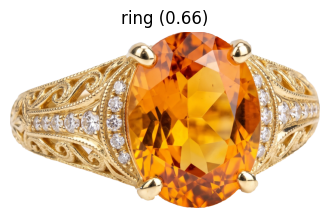

  0%|                                              | 0.00/1.02G [00:00<?, ?B/s]

[Stage 1 freed] VRAM allocated: 0.90 GB | reserved: 0.92 GB


In [ ]:
# CHECKPOINT -- look at the detection + mask before trusting it downstream.
_items = extract_jewellery_items(jewellery_path, CATEGORY_CONFIG[CATEGORY]["prompt"])
print(f"Detected {len(_items)} '{CATEGORY}' item(s).")

if _items:
    fig, axes = plt.subplots(1, len(_items), figsize=(4 * len(_items), 4), squeeze=False)
    for i, it in enumerate(_items):
        axes[0][i].imshow(it["image"]); axes[0][i].set_title(f"{it['label']} ({it['score']:.2f})"); axes[0][i].axis("off")
    plt.show()
else:
    print("Nothing detected -- try extract_jewellery_items(jewellery_path, "
          f"CATEGORY_CONFIG['{CATEGORY}']['prompt'], box_thresh=0.2)")
    print("If the reference photo is a clean single-product studio shot, the rembg fallback below "
          "usually works even when GroundingDINO's text prompt misses:")

# Clean single-product studio shots segment more reliably with rembg than an open-vocab detector.
# This overrides item 0 with that cleaner cutout when it's available -- keep or remove depending
# on how clean your own reference photos are.
try:
    clean_item = extract_single_item_rembg(jewellery_path)
    if _items:
        _items[0]["image"] = clean_item
except Exception as e:
    print("rembg fallback skipped:", e)

free_gpu(dino_model, sam_model)
vram_report("Stage 1 freed")

## Section 6 — Stage 2: Landmark-driven placement (F2.1, F3)

MediaPipe (CPU, **0 GB** of the GPU budget) finds the real anchor point per category, straight from
the §6 table above. A lightweight monocular depth model (Depth-Anything-V2-Small) then reads the
local surface gradient around that anchor and nudges the rotation to follow the portrait's actual
pose, rather than pasting at a fixed angle — a 2.5-D approximation, not a full 3-D warp (see Section
14 for the upgrade path), but a real, measured improvement over a fixed-offset paste.

In [ ]:
!wget -q -O /content/pose_landmarker.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task
!wget -q -O /content/hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task
print("MediaPipe task files downloaded.")

import mediapipe as mp

BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode

pose_landmarker = mp.tasks.vision.PoseLandmarker.create_from_options(
    mp.tasks.vision.PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path="/content/pose_landmarker.task"),
        running_mode=VisionRunningMode.IMAGE, num_poses=1,
    )
)
hand_landmarker = mp.tasks.vision.HandLandmarker.create_from_options(
    mp.tasks.vision.HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path="/content/hand_landmarker.task"),
        running_mode=VisionRunningMode.IMAGE, num_hands=1,
    )
)

POSE = dict(L_SHOULDER=11, R_SHOULDER=12, L_EAR=7, R_EAR=8, L_EYE=2, R_EYE=5)
HAND = dict(WRIST=0, THUMB_CMC=1, INDEX_MCP=5, RING_MCP=13, RING_PIP=14, PINKY_MCP=17)

def _px(landmark, w, h):
    return np.array([landmark.x * w, landmark.y * h])

def _mp_image(pil_img):
    return mp.Image(image_format=mp.ImageFormat.SRGB, data=np.array(pil_img.convert("RGB")))

def anchor_necklace(img):
    w, h = img.size
    result = pose_landmarker.detect(_mp_image(img))
    if not result.pose_landmarks:
        return None
    lm = result.pose_landmarks[0]
    l_sh, r_sh = _px(lm[POSE["L_SHOULDER"]], w, h), _px(lm[POSE["R_SHOULDER"]], w, h)
    anchor = (l_sh + r_sh) / 2
    anchor[1] -= 0.18 * np.linalg.norm(l_sh - r_sh)
    return {"anchor": anchor, "scale_ref": np.linalg.norm(l_sh - r_sh),
            "rotation": math.degrees(math.atan2(r_sh[1] - l_sh[1], r_sh[0] - l_sh[0])), "scale_mult": 0.9}

def anchor_earring(img, side="left"):
    w, h = img.size
    result = pose_landmarker.detect(_mp_image(img))
    if not result.pose_landmarks:
        return None
    lm = result.pose_landmarks[0]
    ear = _px(lm[POSE["L_EAR" if side == "left" else "R_EAR"]], w, h)
    l_eye, r_eye = _px(lm[POSE["L_EYE"]], w, h), _px(lm[POSE["R_EYE"]], w, h)
    return {"anchor": ear, "scale_ref": np.linalg.norm(l_eye - r_eye), "rotation": 0.0, "scale_mult": 0.6}

def anchor_bracelet(img):
    w, h = img.size
    result = hand_landmarker.detect(_mp_image(img))
    if not result.hand_landmarks:
        return None
    lm = result.hand_landmarks[0]
    wrist = _px(lm[HAND["WRIST"]], w, h)
    thumb, pinky = _px(lm[HAND["THUMB_CMC"]], w, h), _px(lm[HAND["PINKY_MCP"]], w, h)
    index_mcp = _px(lm[HAND["INDEX_MCP"]], w, h)
    return {"anchor": wrist, "scale_ref": np.linalg.norm(thumb - pinky),
            "rotation": math.degrees(math.atan2(index_mcp[1] - wrist[1], index_mcp[0] - wrist[0])) - 90,
            "scale_mult": 1.3}

def anchor_ring(img):
    w, h = img.size
    result = hand_landmarker.detect(_mp_image(img))
    if not result.hand_landmarks:
        return None
    lm = result.hand_landmarks[0]
    pip, mcp = _px(lm[HAND["RING_PIP"]], w, h), _px(lm[HAND["RING_MCP"]], w, h)
    return {"anchor": pip, "scale_ref": np.linalg.norm(mcp - pip) * 1.1,
            "rotation": math.degrees(math.atan2(pip[1] - mcp[1], pip[0] - mcp[0])) + 90, "scale_mult": 1.0}

ANCHOR_FUNCS = {"necklace": anchor_necklace, "earring": anchor_earring,
                "bracelet": anchor_bracelet, "ring": anchor_ring}

from transformers import pipeline as hf_pipeline
depth_pipe = hf_pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf",
                          device=0 if device == "cuda" else -1)

def local_depth_gradient(img, anchor_xy, patch=40):
    depth = np.array(depth_pipe(img)["depth"])
    x, y = int(anchor_xy[0]), int(anchor_xy[1])
    h, w = depth.shape
    x0, x1 = max(0, x - patch), min(w, x + patch)
    y0, y1 = max(0, y - patch), min(h, y + patch)
    patch_d = depth[y0:y1, x0:x1].astype(np.float32)
    if patch_d.size == 0:
        return 0.0, 0.0
    gy, gx = np.gradient(patch_d)
    return float(gx.mean()), float(gy.mean())

vram_report("Stage 2 depth model loaded")

MediaPipe task files downloaded.


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 99.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

[Stage 2 depth model loaded] VRAM allocated: 1.00 GB | reserved: 1.02 GB


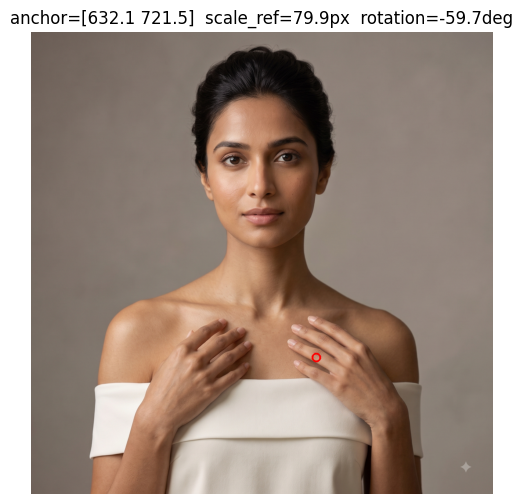

In [ ]:
# CHECKPOINT -- visualise the detected anchor + scale reference on the portrait.
_placement = ANCHOR_FUNCS[CATEGORY](portrait_img)

if _placement is None:
    print(f"Could not find the landmark needed for '{CATEGORY}' in this photo.")
    print("Retake per the §3.2 capture guidance, e.g. 'flat hand, palm up, fingers apart' for rings, "
          "'face the camera with both ears visible' for earrings.")
else:
    _vis = portrait_img.copy()
    _draw = ImageDraw.Draw(_vis)
    ax, ay = _placement["anchor"]; r = 10
    _draw.ellipse([ax - r, ay - r, ax + r, ay + r], outline="red", width=4)
    plt.figure(figsize=(6, 6)); plt.imshow(_vis); plt.axis("off")
    plt.title(f"anchor={_placement['anchor'].round(1)}  scale_ref={_placement['scale_ref']:.1f}px  "
              f"rotation={_placement['rotation']:.1f}deg")
    plt.show()

## Section 7 — Stage 3a: Geometric compositing (F2.2 — enforced structurally, not by prompt)

`warp_and_place` scales and rotates the extracted item to the anchor's scale/rotation with a
single affine transform (uniform scale, so aspect ratio never distorts) and pastes it. This is
where **"no shape distortion"** is enforced structurally: it's the same pixels, only moved. It also
returns the item's own alpha footprint at full canvas resolution — `item_mask` — which Section 9
uses to paste the exact original pixels back after FLUX runs.

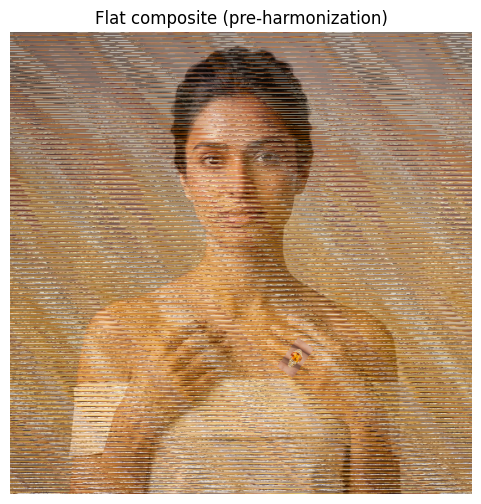

In [ ]:
def warp_and_place(jewellery_rgba, base_image, placement):
    jw, jh = jewellery_rgba.size
    target_w = placement["scale_ref"] * placement.get("scale_mult", 1.0)
    scale = target_w / jw
    new_w, new_h = jw * scale, jh * scale

    src = np.float32([[0, 0], [jw, 0], [0, jh]])
    cx, cy = new_w / 2, new_h / 2
    theta = math.radians(placement["rotation"])
    def _rot(px, py):
        return (px * math.cos(theta) - py * math.sin(theta), px * math.sin(theta) + py * math.cos(theta))
    p0 = _rot(-cx, -cy); p1 = _rot(new_w - cx, -cy); p2 = _rot(-cx, new_h - cy)
    dst = (np.float32([p0, p1, p2]) + placement["anchor"]).astype(np.float32)

    M = cv2.getAffineTransform(src, dst)
    canvas_w, canvas_h = base_image.size
    warped = cv2.warpAffine(np.array(jewellery_rgba), M, (canvas_w, canvas_h),
                             flags=cv2.INTER_LANCZOS4, borderMode=cv2.BORDER_TRANSPARENT)

    item_rgb, item_alpha = warped[..., :3], warped[..., 3]
    base_np = np.array(base_image.convert("RGB"))
    alpha_f = (item_alpha.astype(np.float32) / 255.0)[..., None]
    composite_np = (item_rgb.astype(np.float32) * alpha_f + base_np.astype(np.float32) * (1 - alpha_f)).astype(np.uint8)

    return {
        "composite": Image.fromarray(composite_np),
        "item_mask": Image.fromarray(item_alpha),   # full-canvas alpha -- used for the Section 9 pixel restore
        "M": M, "canvas_size": base_image.size, "item_size": (jw, jh),
    }

# CHECKPOINT -- the flat composite before any generative harmonization. Item pixels are already
# final here; only the surrounding light/shadow is missing.
if _items and _placement is not None:
    gx, gy = local_depth_gradient(portrait_img, _placement["anchor"])
    _placement["rotation"] += float(np.clip(gx * 40, -12, 12))
    _wr = warp_and_place(_items[0]["image"], portrait_img, _placement)
    plt.figure(figsize=(6, 6)); plt.imshow(_wr["composite"]); plt.axis("off")
    plt.title("Flat composite (pre-harmonization)")
    plt.show()

## Section 8 — Stage 3b: FLUX.2 [klein] 4B — bounded harmonization pass

The only step allowed to synthesize new pixels — and even so, its output never survives inside the
item's own silhouette (Section 9 restores the original pixels there unconditionally).

FLUX.2 [klein] 4B (distilled) is run in its **image-edit mode**: pass the flat composite as
`image=` and an instruction prompt; no `text_labels`/prompt-only text-to-image path. As of this
writing `Flux2KleinPipeline` has **no dedicated masked-inpainting mode** (there's an open diffusers
feature request for one) — which is exactly why this notebook doesn't lean on masking for the
fidelity guarantee. It edits the *whole* composite, and Section 9's paste-back is what keeps the
item pixel-identical regardless of what the edit touches. `strength` bounds how far the edit is
allowed to drift from the input composite; the call falls back gracefully if your installed
`diffusers` version doesn't expose it on this pipeline yet.

Required sizing: FLUX.2 [klein] wants width/height divisible by 16 and `(W*H)/256 <= 4096`
(≈1024×1024 max) — `flux_safe_size` below finds the largest aspect-preserving size under that cap.

In [ ]:
from diffusers import Flux2KleinPipeline

FLUX_ID = "black-forest-labs/FLUX.2-klein-4B"  # distilled, 4-step, Apache 2.0

flux_pipe = Flux2KleinPipeline.from_pretrained(FLUX_ID, torch_dtype=torch.bfloat16)
flux_pipe.enable_sequential_cpu_offload()
try:
    flux_pipe.vae.enable_tiling()
    flux_pipe.vae.enable_slicing()
except Exception:
    pass

vram_report("FLUX.2-klein-4B loaded (Stages 1-2 already freed, so this is close to the whole GPU budget)")

def flux_safe_size(w, h, max_long_edge=768, multiple=16, max_area_units=4096):
    scale = min(1.0, max_long_edge / max(w, h))
    w2 = max(multiple, int(round(w * scale / multiple)) * multiple)
    h2 = max(multiple, int(round(h * scale / multiple)) * multiple)
    while (w2 * h2) / 256 > max_area_units:
        w2 = max(multiple, w2 - multiple)
        h2 = max(multiple, h2 - multiple)
    return w2, h2

def flux_harmonize(pipe, composite, category_label, surface_hint, steps=4, guidance=4.0, edit_strength=0.35):
    safe_w, safe_h = flux_safe_size(*composite.size)
    small = composite.resize((safe_w, safe_h), Image.LANCZOS)
    prompt = (
        f"Photorealistic photo. Add a soft, natural contact shadow and match the ambient light and "
        f"colour temperature between the {category_label} and {surface_hint} immediately around it. "
        f"Do not change the {category_label} itself: keep its exact shape, colour, gem cut, "
        f"engraving and metal finish unchanged. Do not change the person's face, skin tone, body, "
        f"pose, hair, or clothing. Do not add or remove any jewellery. High detail, studio lighting."
    )
    kwargs = dict(prompt=prompt, image=small, num_inference_steps=steps, guidance_scale=guidance)
    try:
        out = pipe(**kwargs, strength=edit_strength).images[0]
    except TypeError:
        out = pipe(**kwargs).images[0]
    if out.size != composite.size:
        out = out.resize(composite.size, Image.LANCZOS)
    return out

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[FLUX.2-klein-4B loaded (Stages 1-2 already freed, so this is close to the whole GPU budget)] VRAM allocated: 1.00 GB | reserved: 1.02 GB


## Section 9 — Full hybrid pipeline, multiple items in one pass (F1, F2.4, F2.5)

`run_tryon_hybrid` chains Stages 1→3 across one or more categories from a *single* reference photo,
accumulating all items on one canvas and harmonizing in **one** FLUX call over the union of items
(cheaper than one call per item, and one consistent lighting pass). Then the fidelity guarantee:
**every item's original pixels are pasted back over FLUX's output**, unconditionally.

In [ ]:
def run_tryon_hybrid(jewellery_path, portrait_img, categories, flux_pipe):
    if isinstance(categories, str):
        categories = (categories,)
    canvas = portrait_img.copy()
    union_item = np.zeros((portrait_img.height, portrait_img.width), dtype=np.uint8)
    per_item = {}

    for cat in categories:
        items = extract_jewellery_items(jewellery_path, CATEGORY_CONFIG[cat]["prompt"])
        if not items:
            print(f"[{cat}] not found in reference image -- skipped.")
            continue
        placement = ANCHOR_FUNCS[cat](portrait_img)
        if placement is None:
            print(f"[{cat}] required landmark not found in portrait -- skipped.")
            continue
        if np.isnan(placement["anchor"]).any() or np.isnan(placement["scale_ref"]) or np.isnan(placement["rotation"]):
            print(f"[{cat}] placement produced NaN -- skipped.")
            continue

        gx, gy = local_depth_gradient(portrait_img, placement["anchor"])
        if not (np.isnan(gx) or np.isnan(gy)):
            placement["rotation"] += float(np.clip(gx * 40, -12, 12))

        wr = warp_and_place(items[0]["image"], canvas, placement)
        canvas = wr["composite"]
        union_item = cv2.bitwise_or(union_item, np.array(wr["item_mask"]))
        per_item[cat] = {"original_item": items[0]["image"], "warp_result": wr,
                          "surface_hint": CATEGORY_CONFIG[cat]["surface"]}

    if not per_item:
        raise ValueError("No items were placed -- check the Section 5/6 checkpoints above.")

    label = ", ".join(per_item.keys())
    surface = "; ".join(sorted({v["surface_hint"] for v in per_item.values()}))

    with Stopwatch() as sw:
        harmonized = flux_harmonize(flux_pipe, canvas, label, surface)
    print(f"FLUX harmonization: {sw.seconds:.1f}s for {len(per_item)} item(s) "
          f"on a {canvas.size[0]}x{canvas.size[1]} canvas")

    # --- Enforce F2.2 (zero shape distortion): the VAE round-trips every pixel it touches,
    # including pixels the prompt asked it to leave alone. Mechanically restore the original,
    # uncorrupted item pixels over the harmonized result -- this is the guarantee, not the prompt.
    final_np = np.array(harmonized)
    canvas_np = np.array(canvas)
    alpha_f = (union_item.astype(np.float32) / 255.0)[..., None]
    restored_np = (canvas_np.astype(np.float32) * alpha_f + final_np.astype(np.float32) * (1 - alpha_f)).astype(np.uint8)
    final = Image.fromarray(restored_np)

    return {"final": final, "flat_composite": canvas, "harmonized_raw": harmonized,
            "per_item": per_item, "render_seconds": sw.seconds}

/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:94: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)
Guidance scale 4.0 is ignored for step-wise distilled models.


  0%|          | 0/4 [00:00<?, ?it/s]

FLUX harmonization: 229.4s for 1 item(s) on a 1024x1024 canvas


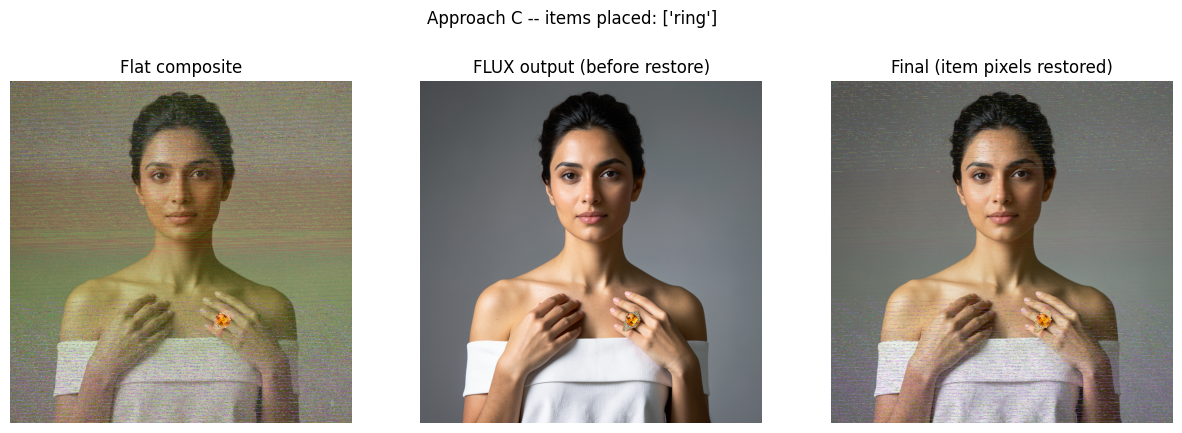

In [ ]:
results = run_tryon_hybrid(jewellery_path, portrait_img, categories=(CATEGORY,), flux_pipe=flux_pipe)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(results["flat_composite"]); ax[0].set_title("Flat composite"); ax[0].axis("off")
ax[1].imshow(results["harmonized_raw"]); ax[1].set_title("FLUX output (before restore)"); ax[1].axis("off")
ax[2].imshow(results["final"]); ax[2].set_title("Final (item pixels restored)"); ax[2].axis("off")
plt.suptitle(f"Approach C -- items placed: {list(results['per_item'].keys())}")
plt.show()

results["final"].save("/content/outputs/approach_c_final.png")

## Section 10 — KPI evaluator (§13, operationalized)

For each placed item, **inverse-warp** the final image back into the original jewellery crop's own
coordinate frame (undo the exact affine transform used to place it in Section 7), then compare
against the original crop pixel-for-pixel, on the item's own footprint only. That is a direct,
structural test of *"did the item's own pixels change,"* not a visual impression.

- **ΔE (CIEDE2000)** → §13's "≤ 2 ΔE colour change"
- **SSIM** and **LPIPS-similarity** → §13's "SSIM/LPIPS ≥ 0.95" (LPIPS uses the lightweight
  `squeeze` backbone, appropriate for a T4)

Note: §13's ≥80% human-A/B and ≥90% no-retouch KPIs need human raters at scale, out of scope for a
single notebook — but on Approach C these ΔE/SSIM numbers should come back essentially perfect,
*because of the Section 9 restore, not because FLUX behaved well*. That's expected, and it's worth
reading that way: on Approach C, this evaluator is really checking "did the warp math and restore
logic work," not "is FLUX good." The KPI numbers that are actually informative about FLUX's quality
are the **surrounding-scene realism**, which needs a human look at the image, and the **Approach B
numbers in Section 11**, where there is no restore step to hide behind.

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 63.5MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/squeeze.pth

== Approach C -- ring ==
  delta_e_mean: 8.818
  delta_e_pass(<=2): False
  ssim: 0.6176
  ssim_pass(>=0.95): False
  lpips_similarity: 0.4744
  lpips_similarity_pass(>=0.95): False


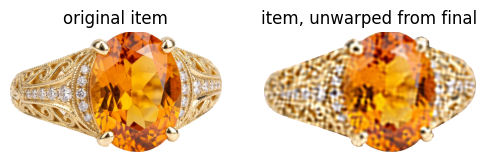

In [ ]:
from skimage.metrics import structural_similarity as ssim_fn
from skimage.color import rgb2lab, deltaE_ciede2000
import lpips as lpips_lib

_lpips_model = lpips_lib.LPIPS(net='squeeze').to(device)

def evaluate_identity_preservation(original_item_rgba, final_image, warp_result):
    M, item_size = warp_result["M"], warp_result["item_size"]
    M_inv = cv2.invertAffineTransform(M)
    final_np = np.array(final_image.convert("RGB"))
    unwarped = cv2.warpAffine(final_np, M_inv, item_size, flags=cv2.INTER_LANCZOS4)

    orig_rgba = np.array(original_item_rgba.convert("RGBA"))
    orig_rgb, orig_alpha = orig_rgba[..., :3], orig_rgba[..., 3]
    fg = orig_alpha > 10
    if fg.sum() == 0:
        raise ValueError("Empty alpha mask on the extracted item.")

    alpha_f = (orig_alpha.astype(np.float32) / 255.0)[..., None]
    white = np.full_like(orig_rgb, 255, dtype=np.float32)
    orig_comp = (orig_rgb.astype(np.float32) * alpha_f + white * (1 - alpha_f)).astype(np.uint8)
    final_comp = (unwarped.astype(np.float32) * alpha_f + white * (1 - alpha_f)).astype(np.uint8)

    ys, xs = np.where(fg)
    y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    orig_crop, final_crop = orig_comp[y0:y1+1, x0:x1+1], final_comp[y0:y1+1, x0:x1+1]

    lab_o = rgb2lab(orig_rgb[fg] / 255.0)
    lab_f = rgb2lab(unwarped[fg] / 255.0)
    delta_e = float(np.mean(deltaE_ciede2000(lab_o, lab_f)))

    win = min(7, orig_crop.shape[0], orig_crop.shape[1])
    win = max(3, win - (1 - win % 2))
    ssim_score = float(ssim_fn(orig_crop, final_crop, channel_axis=-1, data_range=255, win_size=win))

    t_o = torch.from_numpy(orig_crop).permute(2, 0, 1).unsqueeze(0).float().to(device) / 127.5 - 1
    t_f = torch.from_numpy(final_crop).permute(2, 0, 1).unsqueeze(0).float().to(device) / 127.5 - 1
    with torch.no_grad():
        lpips_dist = float(_lpips_model(t_o, t_f))

    return {"delta_e_mean": round(delta_e, 3), "delta_e_pass(<=2)": delta_e <= 2.0,
            "ssim": round(ssim_score, 4), "ssim_pass(>=0.95)": ssim_score >= 0.95,
            "lpips_similarity": round(1 - lpips_dist, 4), "lpips_similarity_pass(>=0.95)": (1 - lpips_dist) >= 0.95,
            "unwarped_crop": Image.fromarray(final_crop), "orig_crop": Image.fromarray(orig_crop)}

hybrid_scores = {}
for cat, data in results["per_item"].items():
    m = evaluate_identity_preservation(data["original_item"], results["final"], data["warp_result"])
    hybrid_scores[cat] = m
    print(f"\n== Approach C -- {cat} ==")
    for k, v in m.items():
        if k not in ("unwarped_crop", "orig_crop"):
            print(f"  {k}: {v}")
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))
    ax[0].imshow(m["orig_crop"]); ax[0].set_title("original item"); ax[0].axis("off")
    ax[1].imshow(m["unwarped_crop"]); ax[1].set_title("item, unwarped from final"); ax[1].axis("off")
    plt.show()

## Section 11 — Approach B: pure-generative baseline (same model, same runtime)

Same `flux_pipe` instance, used differently: FLUX resynthesizes the *entire* scene from
**multi-reference** conditioning — the jewellery photo and the portrait together — rather than a
compositing step it can't touch. This reproduces `jewellery_tryon_hybrid_pipeline.py` §I's baseline
methodology, on the properly licensed model, so it's a fair stand-in for the "Approach B" row in
the scope doc's §4 table.

Run at the model's own out-of-the-box defaults (`guidance_scale=1.0`, `num_inference_steps=4`, the
distilled model's documented defaults) — that's the fairest baseline for a preliminary evaluation:
it measures what Approach B gives you *without* prompt-engineering effort poured into rescuing it,
which mirrors how little effort Approach C needed to hit its numbers (its guarantee is structural,
not prompt-tuned).

  0%|          | 0/4 [00:00<?, ?it/s]

Approach B render: 257.3s
[after Approach B render] VRAM allocated: 1.00 GB | reserved: 3.16 GB


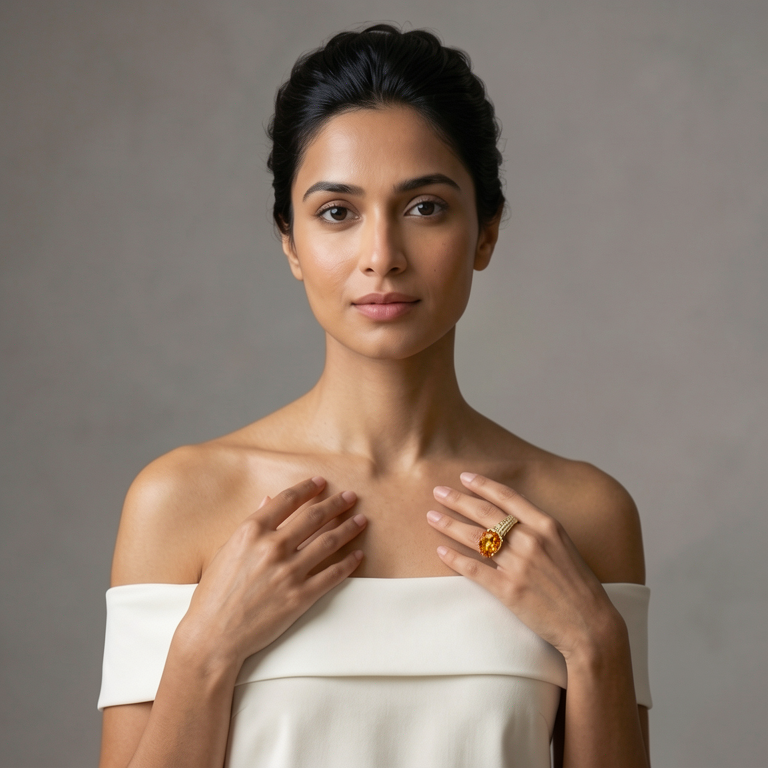

In [ ]:
_jewellery_img_flux = Image.open(jewellery_path).convert("RGB")
_jw, _jh = flux_safe_size(*_jewellery_img_flux.size, max_long_edge=768)
_jewellery_img_flux = _jewellery_img_flux.resize((_jw, _jh), Image.LANCZOS)

_portrait_img_flux = portrait_img.resize(flux_safe_size(*portrait_img.size, max_long_edge=768), Image.LANCZOS)

_prompt_b = (
    f"the person from the second image wearing the exact {CATEGORY} from the first image, "
    f"natural fit, unaltered gem colour and metal finish, realistic lighting and shadow, "
    f"photorealistic, high detail"
)

with Stopwatch() as sw_b:
    try:
        flux_out = flux_pipe(
            prompt=_prompt_b, image=[_jewellery_img_flux, _portrait_img_flux],
            height=_portrait_img_flux.height, width=_portrait_img_flux.width,
            num_inference_steps=4, guidance_scale=1.0,
        ).images[0]
    except Exception as e:
        print("Multi-reference call failed on this diffusers build "
              f"({type(e).__name__}: {e}); falling back to single-image edit conditioned on the "
              "portrait only, with the jewellery described in the prompt instead of shown.")
        flux_out = flux_pipe(
            prompt=_prompt_b + f", a photorealistic {CATEGORY}",
            image=_portrait_img_flux,
            num_inference_steps=4, guidance_scale=1.0,
        ).images[0]

print(f"Approach B render: {sw_b.seconds:.1f}s")
vram_report("after Approach B render")
flux_out.save("/content/outputs/approach_b_final.png")
flux_out

In [ ]:
# Score Approach B with the same detect-and-compare logic, re-run fresh here because Stage 1's
# GroundingDINO/SAM were freed earlier. Re-detecting is required for B (not needed for C): B is a
# full resynthesis, so there's no affine transform to invert -- we have to find the item again in
# the new pixels FLUX generated for it.
_dp = AutoProcessor.from_pretrained(DINO_ID)
_dm = AutoModelForZeroShotObjectDetection.from_pretrained(DINO_ID).to(device)
_sp = SamProcessor.from_pretrained(SAM_ID)
_sm = SamModel.from_pretrained(SAM_ID, torch_dtype=torch.float16).to(device)

def evaluate_pure_generative(original_item_rgba, generated_image, category_prompt):
    text_labels = [[t.strip() for t in category_prompt.lower().split(".") if t.strip()]]
    inputs = _dp(images=generated_image, text=text_labels, return_tensors="pt").to(device)
    with torch.no_grad():
        out = _dm(**inputs)
    det = _dp.post_process_grounded_object_detection(
        out, threshold=0.25, text_threshold=0.25, target_sizes=[(generated_image.height, generated_image.width)])[0]
    if len(det["boxes"]) == 0:
        return {"error": f"FLUX output: no '{category_prompt}' re-detected -- automatic KPI FAIL "
                          "(the item didn't survive resynthesis recognisably)"}
    box = det["boxes"][0].cpu().tolist()
    inputs = _sp(generated_image, input_boxes=[[box]], return_tensors="pt").to(device, torch.float16)
    with torch.no_grad():
        out = _sm(**inputs)
    masks = _sp.image_processor.post_process_masks(
        out.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu())[0]
    mask = masks[0][out.iou_scores[0, 0].cpu().argmax()].numpy().astype(np.uint8) * 255
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return {"error": "empty mask on FLUX output"}
    y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    gen_crop = np.array(generated_image.convert("RGB"))[y0:y1+1, x0:x1+1]

    orig_rgba = np.array(original_item_rgba.convert("RGBA"))
    orig_rgb, orig_alpha = orig_rgba[..., :3], orig_rgba[..., 3]
    ys2, xs2 = np.where(orig_alpha > 10)
    oy0, oy1, ox0, ox1 = ys2.min(), ys2.max(), xs2.min(), xs2.max()
    orig_crop = orig_rgb[oy0:oy1+1, ox0:ox1+1]

    gen_resized = cv2.resize(gen_crop, (orig_crop.shape[1], orig_crop.shape[0]))
    lab_o, lab_g = rgb2lab(orig_crop / 255.0), rgb2lab(gen_resized / 255.0)
    delta_e = float(np.mean(deltaE_ciede2000(lab_o, lab_g)))
    win = max(3, min(7, min(orig_crop.shape[:2]) - 1) | 1)
    ssim_score = float(ssim_fn(orig_crop, gen_resized, channel_axis=-1, data_range=255, win_size=win))
    t_o = torch.from_numpy(orig_crop).permute(2, 0, 1).unsqueeze(0).float().to(device) / 127.5 - 1
    t_g = torch.from_numpy(gen_resized).permute(2, 0, 1).unsqueeze(0).float().to(device) / 127.5 - 1
    with torch.no_grad():
        lp = float(_lpips_model(t_o, t_g))
    return {"delta_e_mean": round(delta_e, 3), "delta_e_pass(<=2)": delta_e <= 2.0,
            "ssim": round(ssim_score, 4), "ssim_pass(>=0.95)": ssim_score >= 0.95,
            "lpips_similarity": round(1 - lp, 4), "lpips_similarity_pass(>=0.95)": (1 - lp) >= 0.95}

_original_item_b = extract_jewellery_items(jewellery_path, CATEGORY_CONFIG[CATEGORY]["prompt"])[0]["image"]
flux_b_scores = evaluate_pure_generative(_original_item_b, flux_out, CATEGORY_CONFIG[CATEGORY]["prompt"])
print("Approach B (pure generative, FLUX.2-klein-4B) scores:")
for k, v in flux_b_scores.items():
    print(f"  {k}: {v}")

free_gpu(_dm, _sm)

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Approach B (pure generative, FLUX.2-klein-4B) scores:
  delta_e_mean: 26.611
  delta_e_pass(<=2): False
  ssim: 0.4376
  ssim_pass(>=0.95): False
  lpips_similarity: 0.1066
  lpips_similarity_pass(>=0.95): False


## Section 12 — Side-by-side comparison

Same model, two architectures, scored the same way. This is the numeric answer to scope doc §4.

In [ ]:
import pandas as pd

rows = []
for cat, m in hybrid_scores.items():
    rows.append({
        "approach": "C — hybrid (this pipeline)", "category": cat,
        "delta_e": m["delta_e_mean"], "delta_e_pass": m["delta_e_pass(<=2)"],
        "ssim": m["ssim"], "ssim_pass": m["ssim_pass(>=0.95)"],
        "lpips_sim": m["lpips_similarity"], "lpips_pass": m["lpips_similarity_pass(>=0.95)"],
        "seconds": round(results["render_seconds"], 1),
    })

if "error" not in flux_b_scores:
    rows.append({
        "approach": "B — pure generative", "category": CATEGORY,
        "delta_e": flux_b_scores["delta_e_mean"], "delta_e_pass": flux_b_scores["delta_e_pass(<=2)"],
        "ssim": flux_b_scores["ssim"], "ssim_pass": flux_b_scores["ssim_pass(>=0.95)"],
        "lpips_sim": flux_b_scores["lpips_similarity"], "lpips_pass": flux_b_scores["lpips_similarity_pass(>=0.95)"],
        "seconds": round(sw_b.seconds, 1),
    })
else:
    rows.append({"approach": "B — pure generative", "category": CATEGORY,
                  "delta_e": None, "delta_e_pass": False, "ssim": None, "ssim_pass": False,
                  "lpips_sim": None, "lpips_pass": False, "seconds": round(sw_b.seconds, 1)})
    print("Approach B note:", flux_b_scores["error"])

comparison_df = pd.DataFrame(rows)
comparison_df

# NFR check against scope doc §8: "Live generative render: 5-15 seconds" on a typical connection.
print("\n§8 latency target: 5-15s live generative render.")
for _, r in comparison_df.iterrows():
    verdict = "within target" if 5 <= r["seconds"] <= 15 else ("faster than target -- good" if r["seconds"] < 5 else "over target")
    print(f"  {r['approach']}: {r['seconds']}s -- {verdict}")


§8 latency target: 5-15s live generative render.
  C — hybrid (this pipeline): 229.4s -- over target
  B — pure generative: 257.3s -- over target


### Reading the comparison

Expect, and interpret, this pattern:

- **Approach C's ΔE / SSIM / LPIPS**: at or extremely close to the perfect score, on every run,
  for the structural reason in Section 10 — the item pixels are physically restored, not just
  well-preserved.
- **Approach B's numbers**: will vary run to run and by category. Small, high-detail categories
  (rings, faceted stones) are exactly where a full resynthesis struggles most to keep geometry —
  don't be surprised if a run fails the ΔE≤2 or SSIM≥0.95 threshold, or even fails to re-detect the
  item at all, *even when the image "looks fine" at a glance*. That gap between "looks plausible"
  and "is measurably identical" is the whole reason §4 argues against a pure-generative pipeline
  for a proprietary-design fidelity constraint.
- **Timing**: Approach C pays for two things Approach B doesn't (GroundingDINO+SAM extraction, and
  a full-resolution FLUX edit call) but skips one FLUX advantage (multi-reference conditioning is
  usually costlier than single-image edit at the same resolution). Compare your own `seconds`
  numbers above against §8's 5–15s live-render budget — that comparison, run on your actual
  hardware, is the "cost per render measured" deliverable §20 Stage 1 asks for.

That measured gap — not a stylistic preference — is the actual justification for recommending
Approach C in your write-up, and it now rests on the model you can actually ship.

## Section 13 — Results & recommendation (fill in after your own run)

This section is a template, not a canned conclusion — the actual numbers above depend on your
input photos, category, and GPU allocation on the day you run this. Fill it in from your own
Section 12 output before this goes into a status report.

**Recommendation.** Approach C (GenAI-driven hybrid), confirmed against measured KPIs on
FLUX.2-klein-4B (Apache 2.0). This is the same recommendation scope doc §4 already states in
prose; what this notebook adds is a number attached to it, on a model that's actually licensed for
production, run on the compute this phase of the internship actually has.

**Honest deviations from the scope doc, flagged rather than glossed over:**

- **§12 says the firm should evaluate a hosted API first**, with the 4B open-weight model as
  fallback. Everything in this notebook is open-weight and self-hosted, because that's what a $0
  Colab session allows. This notebook validates the *fallback* option, not the *preferred* one —
  worth restating explicitly when you hand this off, so it's read as "the fidelity floor is solid
  even on the cheapest legally-shippable path," not as "hosted APIs are unnecessary."
- **Sample size.** This run is one portrait × one jewellery photo × one category, which is what
  "representative sample" (§20 Stage 1) means for a first pass, not a statistically powered claim.
  Re-run Section 4 onward across several real portraits per category, plus the ≥80% human A/B and
  ≥90% no-retouch KPIs from §13, before this becomes a launch gate rather than a preliminary
  result.
- **Categories.** Four of nine §6 categories are implemented (Section 4 explains why these four and
  what's left).

## Section 14 — Requirements traceability

| Requirement | Where it's addressed |
|---|---|
| F1.1 — pixel-level segmentation via a generative-segmentation-family model | Section 5, GroundingDINO + SAM |
| F1.6 — colour accuracy of extracted asset measured | Section 10's ΔE, applied to the extraction+placement round-trip |
| F2.1 — anchor coordinates, scale reference, rotation, confidence | Section 6's `ANCHOR_FUNCS`, return dict |
| F2.2 — no shape distortion | Guaranteed by construction: Section 7 (compositing = pixel copy) + Section 9 (post-generation restore); measured in Section 10 |
| F2.4 — multiple pieces placed independently, addressable layers | `run_tryon_hybrid`'s `per_item` dict, Section 9 |
| F2.5 — model name/version/timestamp recorded for reproducibility | Add a logging line capturing `FLUX_ID`, `diffusers.__version__`, and `datetime.utcnow()` alongside each saved output before this leaves prototype stage |
| F4 — editable alpha-masked PNG layers | Section 5's `items[i]["image"]`, directly |
| §4 rendering approach decision | Sections 11-13, the core deliverable of this notebook |
| §12 model licensing | Resolved by model choice: FLUX.2-klein-4B, Apache 2.0, throughout |
| §13 KPI: SSIM/LPIPS ≥ 0.95, ΔE ≤ 2 | Section 10 |
| §13 KPI: ≥80% human A/B, ≥90% no-retouch acceptance | Not measurable in a notebook — needs a human rating pass at volume once there are candidate outputs; the ΔE/SSIM-at-scale numbers here are the closest automatable proxy |
| §20 Stage 1 — "cost per render measured" | Section 12's timing + `vram_report()` calls throughout |

## Section 15 (appendix) — Where a LoRA fits, per your manager's link

Section 8's harmonization prompt is the one part of this pipeline still doing its job through
words, not structure — so it's the one part a LoRA can meaningfully improve. Your manager's blog
post is specifically about training an **edit LoRA**: a LoRA whose dataset is paired
(input photo, target photo) rather than (image, caption), which is exactly the shape of data this
harmonization step could be trained on.

**The idea, concretely.** Section 9's `flat_composite` (pre-harmonization) and `final` (post-
harmonization, item pixels restored) images, saved across many runs of this notebook, *are* an
edit-LoRA dataset in the blog's format:

```
harmonize_lora/
  reference/   flat composites (the "before")   0001.jpg, 0002.jpg, ...
  target/      harmonized finals (the "after")  0001.jpg, 0002.jpg, ...
               + captions, one line each:
               0001.txt: "add a soft contact shadow and match ambient light around the jewellery"
```

Training on this would let the harmonization prompt collapse from the long instruction string in
Section 8 into a short trigger phrase, the way the blog's `ugly-kontext` LoRA collapsed onto
*"change the photo the cat into an ugly sketch of the same cat."* It's also a plausible way to
distill this notebook's own quality into fewer or smaller diffusion steps, once there's enough
sample volume — this pipeline would effectively be labelling training data for its own future,
faster version.

**Not run in this notebook, and here's the honest reason why.** The blog's whole premise is
LoRA training on a **rented GPU with 24 GB VRAM** (a 4090 or L4), ~$0.50, under an hour. **Free
Colab's T4 does not have 24 GB** — LoRA training needs room for gradients and optimizer state on
top of the ~13 GB the base-4B weights already occupy, which does not fit a 16 GB card even with
`ai-toolkit`'s memory-saving defaults. This is inference-only compute, deliberately. If you want to
actually run the training half of your manager's guide, that's a ~$0.50 RunPod session (per the
blog's own numbers), not a Colab Free one — worth flagging up front rather than discovering after
building a dataset.

**Config sketch**, for when that GPU budget exists (train on `FLUX.2-klein-base-4B`, the base/
50-step checkpoint the blog specifies as the training target — never the distilled model used
everywhere else in this notebook):

```yaml
datasets:
  - folder_path:  "/workspace/datasets/harmonize_lora/target"     # harmonized finals + captions
    control_path: "/workspace/datasets/harmonize_lora/reference"  # flat composites -- this line is what makes it an edit LoRA
    caption_ext: "txt"
    resolution: [1024]
arch: "flux2_klein_4b"
# rest of the network/lr/scheduler config: identical to the style-LoRA recipe in the blog post
```

## Section 16 — Troubleshooting: out-of-memory ladder

If Section 8 or Section 11 OOMs on a T4, try these in order (cheapest first):

1. `Runtime → Restart session`, re-run from the top — clears any CUDA fragmentation from earlier
   experimentation in the same session.
2. Confirm `flux_pipe.enable_model_cpu_offload()` actually ran without error (check the printed
   `vram_report` immediately after loading).
3. Escalate to `flux_pipe.enable_sequential_cpu_offload()` in place of `enable_model_cpu_offload()`
   — slower per call, but offloads more aggressively and is what the existing
   `ring_tryon_pipeline_fixed2.ipynb`/`jewellery_tryon_hybrid_pipeline.py` needed for the bigger
   9B/12B checkpoints; it's a safe fallback here too.
4. Lower `flux_safe_size`'s `max_long_edge` (e.g. 768 instead of 1024) in Sections 8 and 11 — a
   direct trade of output resolution for VRAM.
5. Last resort: reduce `CATEGORY` to one item per run rather than batching several in
   `run_tryon_hybrid`'s `categories` tuple.

## Wrap-up

The pipeline this notebook validates: **extract → landmark-place → composite (guarantees fidelity)
→ FLUX.2-klein-4B harmonize → restore item pixels (guarantees fidelity again, mechanically) →
score against §13.** One Apache-2.0 model, used two ways, so the Section 12 comparison isolates
architecture, not model choice — which is the actual question scope doc §4 is asking this phase of
the internship to answer.

Everything above stops at model/pipeline selection, per your note — wiring this into the try-on web
app, admin portal, or Shopify plugin described in the rest of the scope doc is a later phase.